# Uber Fare Prediction — Ensemble Learning

Combine the individual regressors from `02_model_trainingnew.ipynb` (Linear/Ridge/Lasso/XGBoost) into two ensemble strategies:

- **Voting (Averaging) Regressor** — averages the predictions of several base models.
- **Stacking Regressor** — trains a meta-model on top of the base models' predictions.

All base models and the final ensembles are evaluated with MAE, RMSE, and R², then saved to disk with **joblib** so they can be reloaded later without retraining.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import VotingRegressor, StackingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

pd.set_option('display.max_columns', None)

## 2. Load Data

Same preprocessed dataset used in the main training notebook.

In [2]:
data = pd.read_csv('../data/processed_data.csv')
print("Shape:", data.shape)
data.head()

Shape: (5792, 50)


,Distance (km),Estimated Duration (min),Weather Condition,Rainfall Intensity,Traffic Level,Temperature Level,Holiday,Day Type,Number of Stops Added,Fare (Target),Vehicle Type_Bike,Vehicle Type_Black,Vehicle Type_Comfort,Vehicle Type_Go,Vehicle Type_Mini,Vehicle Type_Pool,Vehicle Type_Premium,Vehicle Type_SUV,Vehicle Type_Sedan,Vehicle Type_XL,Road Type_Expressway,Road Type_Highway,Road Type_Rural Road,Pickup Area Type_Bus Stand,Pickup Area Type_College,Pickup Area Type_Commercial,Pickup Area Type_Hospital,Pickup Area Type_IT Park,Pickup Area Type_Mall,Pickup Area Type_Metro Station,Pickup Area Type_Railway Station,Pickup Area Type_Residential,Drop Area Type_Bus Stand,Drop Area Type_College,Drop Area Type_Commercial,Drop Area Type_Hospital,Drop Area Type_IT Park,Drop Area Type_Mall,Drop Area Type_Metro Station,Drop Area Type_Railway Station,Drop Area Type_Residential,Time Slot_Evening Rush,Time Slot_Late Night,Time Slot_Midday,Time Slot_Morning,Time Slot_Morning Rush,Time Slot_Night,Busy Day_Major Event,Busy Day_Normal,Busy Day_Public Holiday
0,20.81,64.6,0,0,1,4,0,0,0.0,749,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False
1,9.58,40.8,0,0,3,1,1,0,0.0,811,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True
2,5.36,15.4,1,0,1,2,1,0,4.0,30,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,True,False
3,5.00,25.3,3,1,3,1,1,0,0.0,1243,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False
4,18.14,41.8,0,0,0,1,0,0,0.0,30,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False


## 3. Feature / Target Split & Train-Test Split

Identical split (same `random_state`) as the main notebook, so results stay comparable.

In [3]:
X = data.drop(columns=['Fare (Target)'])
y = data['Fare (Target)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (4633, 49)
X_test : (1159, 49)


## 4. Evaluation Helper

In [4]:
results = {}

def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"{name}")
    print(f"  MAE : {mae:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  R2  : {r2:.4f}")

## 5. Base Models

Define and train the individual regressors that will act as the ensemble's building blocks (same hyperparameters as the main notebook). `statsmodels` OLS is excluded here since it doesn't share scikit-learn's estimator API, which `VotingRegressor`/`StackingRegressor` require.

In [5]:
lr_model = LinearRegression()
ridge_model = Ridge(alpha=1.0, random_state=42)
lasso_model = Lasso(alpha=1.0, random_state=42, max_iter=5000)
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

base_models = {
    'Linear Regression': lr_model,
    'Ridge Regression': ridge_model,
    'Lasso Regression': lasso_model,
    'XGBoost': xgb_model,
}

for name, model in base_models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    evaluate_model(name, y_test, preds)

Linear Regression
  MAE : 470.99
  RMSE: 858.80
  R2  : 0.7194
Ridge Regression
  MAE : 470.36
  RMSE: 858.91
  R2  : 0.7193
Lasso Regression
  MAE : 467.16
  RMSE: 859.94
  R2  : 0.7186
XGBoost
  MAE : 188.16
  RMSE: 485.76
  R2  : 0.9102


## 6. Voting Regressor (Averaging Ensemble)

`VotingRegressor` fits all base estimators independently and averages their predictions (optionally weighted). Averaging tends to reduce variance and smooth out individual models' errors, especially when the base models make different kinds of mistakes.

In [6]:
voting_model = VotingRegressor(
    estimators=[
        ('linear', LinearRegression()),
        ('ridge', Ridge(alpha=1.0, random_state=42)),
        ('lasso', Lasso(alpha=1.0, random_state=42, max_iter=5000)),
        ('xgb', XGBRegressor(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, random_state=42
        )),
    ],
    weights=None  # equal weights; tune e.g. [1, 1, 1, 2] to favor XGBoost
)
voting_model.fit(X_train, y_train)

voting_pred = voting_model.predict(X_test)
evaluate_model('Voting Ensemble', y_test, voting_pred)

Voting Ensemble
  MAE : 377.88
  RMSE: 738.18
  R2  : 0.7927


## 7. Stacking Regressor

`StackingRegressor` trains a **meta-model** (here, `Ridge`) on the out-of-fold predictions of the base models, letting it learn how to best combine them rather than just averaging. `cv=5` controls how the out-of-fold predictions used to train the meta-model are generated.

In [7]:
stacking_model = StackingRegressor(
    estimators=[
        ('linear', LinearRegression()),
        ('ridge', Ridge(alpha=1.0, random_state=42)),
        ('lasso', Lasso(alpha=1.0, random_state=42, max_iter=5000)),
        ('xgb', XGBRegressor(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, random_state=42
        )),
    ],
    final_estimator=Ridge(alpha=1.0, random_state=42),
    cv=5,
    n_jobs=-1
)
stacking_model.fit(X_train, y_train)

stacking_pred = stacking_model.predict(X_test)
evaluate_model('Stacking Ensemble', y_test, stacking_pred)

Stacking Ensemble
  MAE : 182.23
  RMSE: 428.28
  R2  : 0.9302


## 8. Model Comparison

All base models plus both ensembles, side by side, sorted by R².

In [8]:
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df.sort_values(by='R2', ascending=False)
comparison_df

,MAE,RMSE,R2
Stacking Ensemble,182.227977,428.283535,0.930204
XGBoost,188.156433,485.760374,0.910213
Voting Ensemble,377.883517,738.176762,0.792658
Linear Regression,470.990370,858.797228,0.719361
Ridge Regression,470.360669,858.909235,0.719287
Lasso Regression,467.161757,859.939203,0.718614


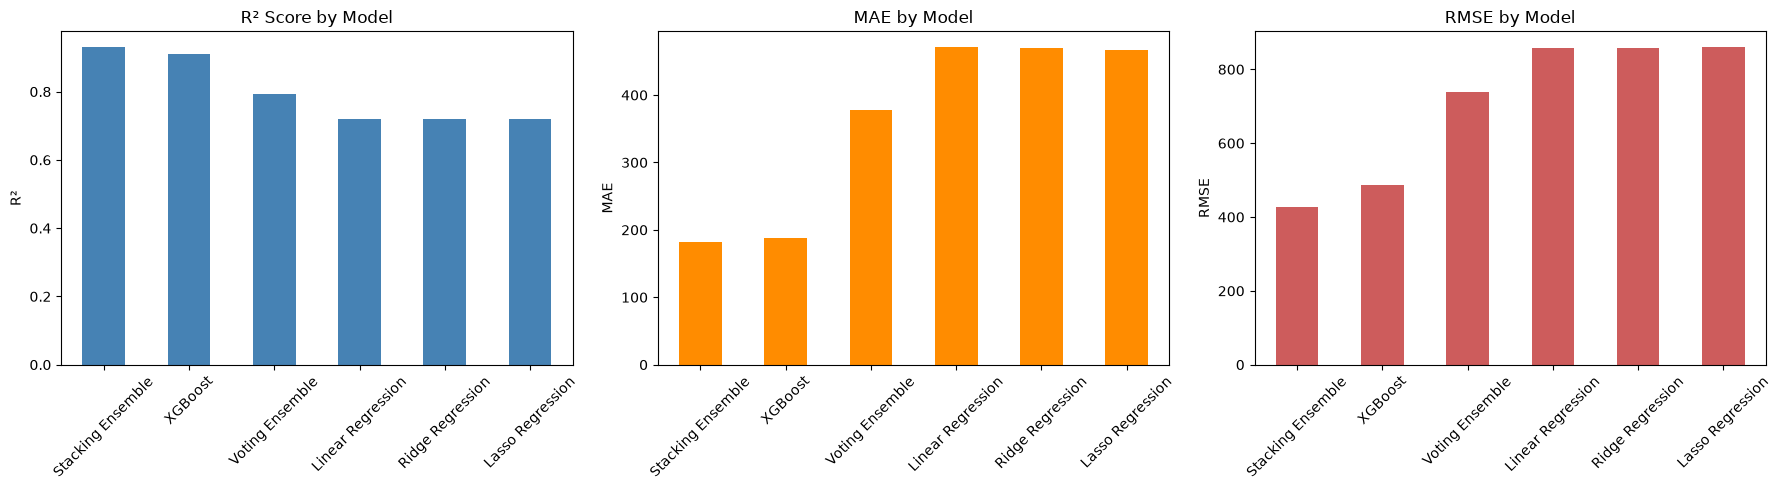

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

comparison_df['R2'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('R² Score by Model')
axes[0].set_ylabel('R²')
axes[0].tick_params(axis='x', rotation=45)

comparison_df['MAE'].plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('MAE by Model')
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=45)

comparison_df['RMSE'].plot(kind='bar', ax=axes[2], color='indianred')
axes[2].set_title('RMSE by Model')
axes[2].set_ylabel('RMSE')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 9. Cross-Validation Check (5-Fold R²) for the Ensembles

Sanity-check both ensembles with 5-fold cross-validation on the training set, same as done for the individual models in the main notebook.

In [10]:
for name, model in [('Voting Ensemble', voting_model), ('Stacking Ensemble', stacking_model)]:
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
    print(f"{name}")
    print(f"  CV R2 scores: {cv_scores}")
    print(f"  Mean CV R2  : {cv_scores.mean():.4f}")

Voting Ensemble
  CV R2 scores: [0.82226725 0.85205102 0.87878803 0.83913144 0.83928738]
  Mean CV R2  : 0.8463
Stacking Ensemble
  CV R2 scores: [0.91875967 0.94709466 0.92481465 0.92614588 0.92178045]
  Mean CV R2  : 0.9277


## 10. Save Models with joblib

Persist every base model and both ensembles to a `models/` folder so they can be reloaded later (e.g. in a deployment script or Streamlit app) without retraining. `joblib` is preferred over `pickle` for scikit-learn/XGBoost models because it handles NumPy arrays more efficiently.

In [13]:
os.makedirs('models', exist_ok=True)

joblib.dump(lr_model, 'models/linear_regression_model.pkl')
joblib.dump(ridge_model, 'models/ridge_regression_model.pkl')
joblib.dump(lasso_model, 'models/lasso_regression_model.pkl')
joblib.dump(xgb_model, 'models/xgboost_model.pkl')
joblib.dump(voting_model, 'models/voting_ensemble_model.pkl')
joblib.dump(stacking_model, 'models/stacking_ensemble_model.pkl')

# Keep the exact feature column order too -- needed to build correctly-shaped
# input rows at inference time (e.g. in the sample-prediction step).
joblib.dump(list(X_train.columns), 'models/feature_columns.pkl')

print("Saved models:", os.listdir('models'))

Saved models: ['feature_columns.pkl', 'lasso_regression_model.pkl', 'linear_regression_model.pkl', 'multiple_regression_ols_model.pkl', 'ridge_regression_model.pkl', 'stacking_ensemble_model.pkl', 'voting_ensemble_model.pkl', 'xgboost_model.pkl']


## 11. Reload & Verify (joblib.load)

Demonstrates loading a saved model back from disk and confirming it reproduces the same predictions -- this is the same pattern to use in any other script/notebook/app that needs the trained ensemble.

In [12]:
loaded_stacking_model = joblib.load('models/stacking_ensemble_model.pkl')
loaded_feature_columns = joblib.load('models/feature_columns.pkl')

reloaded_pred = loaded_stacking_model.predict(X_test[loaded_feature_columns])
print("Predictions match original:", np.allclose(reloaded_pred, stacking_pred))

Predictions match original: True
